# H04/H05：数据修复与补齐历史后的固定模型重验

本 Notebook 继续验证同一候选，协议与状态由 [研究 README](README.md#h04-完整历史重验与新增日期检验) 拥有。旧 H04 Notebook 已归档于 `/home/wsw/app/research-evidence/subscription-revalidation-2026-09-21-plweybse/`；原始输入、模型和失败证据保持不变。

本次对照：**旧数据 → 仅修复 → 修复并增加更早历史**。重点看 Precision@50、Recall、F1 和 Lift；平均收益排名仅作补充。

**本次结果**：已知重复修复通过核验，可用样本扩展到213个目标日。原主候选在后续17日中：仅修复后38/850次命中（4.47%），加入更早历史后34/850（4.00%）；成交额对照146/850（17.18%），随机选择期望约10%。固定模型仍未显示机会密度优势。

扩展组完整134日开发段中，八模型最高 Precision 下界为7.91%，成交额为21.57%、动量为24.45%。这些比较均属于历史重验，参考收益前10%的命中不等于盈利、净收益或实时 L2 的观察价值。

**验证完成**：110个模型重载、2,732个模型日的名单及指标检查、94份未受修复影响的旧预测恢复均通过；10个代码单元从头执行成功。详细认识与后续方向以研究 README 为准。


## 证据说明索引

以下说明于 2026-09-24 从同主题 README 整理迁入，保存各节标注日期的方案、事实与当时解释；迁移不是新的运行或事前登记。当前假设、状态、结论和决定由 [README](README.md) 拥有。历史归档中的源码、Notebook、输入、验收快照和保留期继续有效，精确复现按对应归档说明执行。

- [H04 2026-09-21 冻结方案与验收](#h04-protocol-20260921)
- [H04 2026-09-21 原结果与归档](#h04-evidence-20260921)
- [H04/H05 2026-09-22 修复及补齐历史后的冻结重验方案](#h04-protocol-20260922)
- [H04/H05 2026-09-22 重验结果、失败与归档](#h04-evidence-20260922)
- [H04 2026-09-21 原实验的精确恢复](#h04-reproduce-20260921)
- [H04/H05 2026-09-22 修复重验的精确恢复](#h04-reproduce-20260922)


## 1. 方法与隔离

按 README 中 H04 的修复重验方案执行。模型与机会定义固定，主候选保持原角色，不按本次结果重新挑选后续赢家。当前更正版本用于情景重放：P 22:00 与 T 09:00 就绪是研究假设。

In [1]:
import importlib.metadata
import json
import math
import runpy
import shutil
import subprocess
import tarfile
import tempfile
from pathlib import Path
from typing import TypedDict

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import f1_score, precision_score, recall_score
from threadpoolctl import threadpool_limits

from src.access import Access, meta
from src.utils.path import PathManager

source_root = Path("/home/wsw/app/dev/trading")
topic = source_root / "research/subscription-training"
storage_root = Path("/home/wsw/app/data")
old_training = Path(
    "/home/wsw/app/research-evidence/subscription-revalidation-2026-09-21-plweybse"
)
old_metrics = Path(
    "/home/wsw/app/research-evidence/subscription-opportunity-metrics-2026-09-22-zg1az9fa"
)
evidence = Path(
    tempfile.mkdtemp(
        prefix="subscription-repaired-2026-09-22-", dir=old_training.parent
    )
)
print(f"EVIDENCE={evidence}", flush=True)
api = runpy.run_path(str(topic / "validate_training.py"))
write_json = api["_write_json"]
sha256 = api["_sha256"]
for name in [
    "validate_training.py",
    "revalidation.ipynb",
    "opportunity_metrics.ipynb",
    "README.md",
]:
    shutil.copy2(topic / name, evidence / f"source-{name}")
with tarfile.open(evidence / "source.tar", "w") as archive:
    for path in [
        *sorted((source_root / "src").rglob("*.py")),
        source_root / "pyproject.toml",
        source_root / "uv.lock",
        source_root / "src/config/base.yml",
    ]:
        archive.add(path, arcname=str(path.relative_to(source_root)))


class _Parameters(TypedDict):
    training_seed: int
    bootstrap_seed: int
    bootstrap_repeats: int
    block_lengths: list[int]
    k: int
    strict_event_threshold: float
    session_start: str
    session_end: str
    corrected_target_start: str
    development_end: str
    common_development_start: str
    followup_start: str
    followup_end: str
    candidates: list[str]
    windows: dict[str, int | None]
    rules: list[str]
    primary: str
    followup_roles: dict[str, list[str]]
    readiness: str
    no_new_holdout: bool
    uses_current_repaired_data_vintage: bool
    retention: str


parameters: _Parameters = {
    "training_seed": 20260919,
    "bootstrap_seed": 20260922,
    "bootstrap_repeats": 10000,
    "block_lengths": [5, 1, 3],
    "k": 50,
    "strict_event_threshold": 0.9,
    "session_start": "2025-11-05",
    "session_end": "2026-09-18",
    "corrected_target_start": "2025-12-22",
    "development_end": "2026-08-24",
    "common_development_start": "2026-03-27",
    "followup_start": "2026-08-26",
    "followup_end": "2026-09-17",
    "candidates": ["ridge_daily", "ridge_all", "hist_daily", "hist_all"],
    "windows": {"last60": 60, "expanding": None},
    "rules": ["baseline_amount", "baseline_momentum", "baseline_reversal"],
    "primary": "ridge_all__expanding",
    "followup_roles": {
        "primary": ["ridge_all", "expanding"],
        "ablation": ["ridge_daily", "expanding"],
        "reference": ["hist_all", "last60"],
    },
    "readiness": "P 22:00 features/exit labels; fit T 08:00; model T 09:00; assumed, not historical logs",
    "no_new_holdout": True,
    "uses_current_repaired_data_vintage": True,
    "retention": "until user decision and review complete",
}
write_json(evidence / "parameters.json", parameters)
write_json(
    evidence / "run.json",
    {
        "base_commit": subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=source_root, text=True
        ).strip(),
        "worktree_before": subprocess.check_output(
            ["git", "status", "--short"], cwd=source_root, text=True
        ),
        "training_code_sha256": sha256(topic / "validate_training.py"),
        "source_notebook_sha256": sha256(evidence / "source-revalidation.ipynb"),
        "preregistration_sha256": sha256(evidence / "source-README.md"),
        "source_archive_sha256": sha256(evidence / "source.tar"),
        "versions": {
            name: importlib.metadata.version(name)
            for name in [
                "numpy",
                "pandas",
                "pyarrow",
                "scikit-learn",
                "scipy",
                "joblib",
                "matplotlib",
            ]
        },
        "previous_training": str(old_training),
        "previous_metrics": str(old_metrics),
    },
)
assert sha256(topic / "validate_training.py") == sha256(
    old_training / "validate_training.py"
)
write_json(evidence / "boundary-checks.json", api["_boundary_checks"]())
font_path = evidence / "NotoSansCJKsc-Regular.otf"
shutil.copy2(old_training / font_path.name, font_path)
font_manager.fontManager.addfont(str(font_path))
plt.rcParams.update(
    {
        "font.family": font_manager.FontProperties(fname=font_path).get_name(),
        "font.size": 11,
        "axes.unicode_minus": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    }
)


class _InputFile(TypedDict):
    path: str
    size_bytes: int
    sha256: str

EVIDENCE=/home/wsw/app/research-evidence/subscription-repaired-2026-09-22-2ans6qng


## 2. 冻结输入与检查修复传播

读取当前正式制品并复制到隔离目录。比对维护发布记录的15个分钟、特征和标签 payload；原始压缩包与全量逐笔不在本轮重复解压。6月8/9日窗口按日内时间对齐，检查跨日重复已消除，并逐日检查标签分布。

In [2]:
original_pm = PathManager(storage_root)
sessions = Access(pm=original_pm, processed_version="v1").trade_dates(
    start_date=parameters["session_start"], end_date=parameters["session_end"]
)
assert len(sessions) == 215
snapshot_root = evidence / "inputs"
snapshot_root.mkdir()
for year in (2025, 2026):
    api["_snapshot_object"](
        original_pm,
        original_pm.processed_year_object(
            dataset_name="trade_calendar", version="v1", calendar_year=year
        ),
        snapshot_root,
    )
for position in range(1, len(sessions) - 1):
    previous_day, target_day = sessions[position - 1 : position + 1]
    for feature_set in ["l2_stock_1430", "tushare_daily_basic"]:
        api["_snapshot_object"](
            original_pm,
            original_pm.feature_object(
                feature_set=feature_set, version="v1", trade_date=previous_day
            ),
            snapshot_root,
        )
    api["_snapshot_object"](
        original_pm,
        original_pm.label_object(
            label_set="l2_stock_1430_t1_vwap_rank", version="v1", trade_date=target_day
        ),
        snapshot_root,
    )
manifest: list[_InputFile] = [
    {
        "path": str(path.relative_to(snapshot_root)),
        "size_bytes": path.stat().st_size,
        "sha256": sha256(path),
    }
    for path in sorted(snapshot_root.rglob("*"))
    if path.is_file()
]
write_json(evidence / "input-manifest.json", manifest)
current_hashes = {item["path"]: item["sha256"] for item in manifest}
previous_manifest = json.loads((old_training / "input-manifest.json").read_text())
changed_inputs = [
    item["path"]
    for item in previous_manifest
    if current_hashes[item["path"]] != item["sha256"]
]
changed_payloads = [path for path in changed_inputs if path.endswith(".parquet")]
assert set(changed_payloads) == {
    "features/l2_stock_1430/v1/trade_date=2026-06-09/data.parquet",
    "labels/l2_stock_1430_t1_vwap_rank/v1/trade_date=2026-06-08/data.parquet",
    "labels/l2_stock_1430_t1_vwap_rank/v1/trade_date=2026-06-09/data.parquet",
}
write_json(
    evidence / "changed-inputs.json",
    {"changed_files": changed_inputs, "changed_payloads": changed_payloads},
)
repairs = [
    Path("/home/wsw/app/maintenance-evidence") / name
    for name in [
        "level2-reingest-2026-09-22-__y3ur7e",
        "level2-2025-11-25-ingest-2026-09-22-d9f69dbh",
    ]
]
repair_verified = []
quality_manifest: list[_InputFile] = []
quality_root = evidence / "quality-inputs"
for repair in repairs:
    archive_root = evidence / "maintenance-records" / repair.name
    archive_root.mkdir(parents=True)
    for name in [
        "result.json",
        "published.json",
        "dependency-manifest.json",
        "formal-audit.json",
    ]:
        shutil.copy2(repair / name, archive_root / name)
    published = json.loads((repair / "published.json").read_text())
    for item in published:
        relative = item["payload_path"]
        is_minute = relative.startswith(
            ("processed/sh_stock_trade_1m/", "processed/sz_stock_trade_1m/")
        )
        if not (is_minute or relative.startswith(("features/", "labels/"))):
            continue
        payload = storage_root / relative
        digest = sha256(payload)
        assert digest == item["sha256"] and payload.stat().st_size == item["bytes"]
        meta.require(
            pm=original_pm,
            meta_path=storage_root / item["meta_path"],
            expected_payload_path=payload,
        )
        repair_verified.append(
            {"path": relative, "sha256": digest, "matches_maintenance": True}
        )
        if is_minute:
            for relative_path in [relative, item["meta_path"]]:
                source = storage_root / relative_path
                destination = quality_root / relative_path
                destination.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(source, destination)
                source_hash = sha256(source)
                assert source_hash == sha256(destination)
                quality_manifest.append(
                    {
                        "path": relative_path,
                        "size_bytes": source.stat().st_size,
                        "sha256": source_hash,
                    }
                )
write_json(evidence / "maintenance-verification.json", repair_verified)
write_json(evidence / "quality-input-manifest.json", quality_manifest)
window_frames = {}
for day in ["2026-06-08", "2026-06-09"]:
    parts = []
    for exchange in ["sh", "sz"]:
        path = (
            quality_root
            / f"processed/{exchange}_stock_trade_1m/v1/trade_date={day}/data.parquet"
        )
        frame = pq.ParquetFile(path).read().to_pandas()
        keep = (
            frame["phase"].eq(2)
            & frame["minute_start_ts_utc"].ge(api["_timestamp"](day, 14, 31))
            & frame["minute_start_ts_utc"].lt(api["_timestamp"](day, 14, 36))
        )
        normalized = frame.loc[keep].drop(columns="trade_date").copy()
        normalized["minute_start_ts_utc"] -= api["_timestamp"](day, 0)
        parts.append(normalized)
    window_frames[day] = (
        pd.concat(parts)
        .sort_values(["symbol", "minute_start_ts_utc"])
        .reset_index(drop=True)
    )
assert not window_frames["2026-06-08"].equals(window_frames["2026-06-09"])
profiles = []
for day in sessions[1:-1]:
    path = (
        snapshot_root
        / f"labels/l2_stock_1430_t1_vwap_rank/v1/trade_date={day}/data.parquet"
    )
    frame = pq.ParquetFile(path).read().to_pandas()
    counts = frame["y_rank_return"].value_counts()
    profiles.append(
        {
            "trade_date": day,
            "rows": len(frame),
            "valid_labels": int(frame.y_rank_return.notna().sum()),
            "null_labels": int(frame.y_rank_return.isna().sum()),
            "largest_tie": int(counts.max()),
            "known_opportunities": int(frame.y_rank_return.gt(0.9).sum()),
        }
    )
profile = pd.DataFrame(profiles)
profile.to_csv(evidence / "label-profile.csv", index=False)
assert profile.set_index("trade_date").loc["2026-06-08", "largest_tie"] == 1
write_json(
    evidence / "quality-result.json",
    {
        "verified_repair_payloads": len(repair_verified),
        "window_rows": {day: len(frame) for day, frame in window_frames.items()},
        "june_window_equal": False,
        "max_label_tie": int(profile.largest_tie.max()),
        "largest_tie_2026_06_08": 1,
        "raw_and_ticks_not_reaudited": True,
    },
)
display(
    profile.loc[
        profile.trade_date.isin(
            ["2025-11-24", "2025-11-25", "2026-06-08", "2026-06-09"]
        )
    ]
)
print(
    f"冻结 {len(manifest)} 份训练输入；旧范围恰有 {len(changed_payloads)} 个 payload 改变；{len(repair_verified)} 个分钟/特征/标签与修复证据一致。"
)

,trade_date,rows,valid_labels,null_labels,largest_tie,known_opportunities
12,2025-11-24,5156,5148,8,2,515
13,2025-11-25,5154,5146,8,1,515
140,2026-06-08,5197,5190,7,1,519
141,2026-06-09,5197,5187,10,2,519


冻结 1286 份训练输入；旧范围恰有 3 个 payload 改变；15 个分钟/特征/标签与修复证据一致。


## 3. 确定样本与训练日程

仅修复组沿用181个目标日，扩展组使用213个目标日。两组都使用昨日可见池，不依据未来标签是否存在删掉待选股票。扩展组开发段134日，另单列与原实验相同的102日；后续段仍为原17日。

In [3]:
panel = api["_load_panel"](PathManager(snapshot_root), sessions)
assert not panel.duplicated(["symbol", "trade_date"]).any()
assert panel.source_date.lt(panel.trade_date).all()
assert panel.feature_ready_ts.le(panel.allocation_ts).all()
panel.to_parquet(evidence / "panel.parquet", index=False)
panels = {
    "corrected": panel.loc[
        panel.trade_date.ge(parameters["corrected_target_start"])
    ].copy(),
    "extended": panel,
}
development_dates = {}
followup_dates = {}
panel_rows = []
for experiment, frame in panels.items():
    ready = frame.groupby("trade_date", sort=True).label_ready_ts.max()
    development_dates[experiment] = [
        day
        for day in ready.index
        if day <= parameters["development_end"]
        and int((ready < api["_timestamp"](day, 8)).sum()) >= 60
    ]
    followup_dates[experiment] = [
        day
        for day in ready.index
        if parameters["followup_start"] <= day <= parameters["followup_end"]
    ]
    assert (
        ready.loc[development_dates[experiment]]
        .lt(api["_timestamp"](parameters["followup_start"], 9))
        .all()
    )
    panel_rows.append(
        {
            "experiment": experiment,
            "target_days": len(ready),
            "target_start": frame.trade_date.min(),
            "target_end": frame.trade_date.max(),
            "rows": len(frame),
            "labeled_rows": int(frame.y_rank_return.notna().sum()),
            "development_days": len(development_dates[experiment]),
            "development_start": development_dates[experiment][0],
            "followup_days": len(followup_dates[experiment]),
        }
    )
assert [len(development_dates[name]) for name in panels] == [102, 134]
assert all(len(dates) == 17 for dates in followup_dates.values())
panel_summary = pd.DataFrame(panel_rows)
panel_summary.to_csv(evidence / "panel-summary.csv", index=False)
write_json(
    evidence / "frozen-schedule.json",
    {
        "development": development_dates,
        "followup": followup_dates,
        "primary": parameters["primary"],
        "selection_performed": False,
    },
)
display(panel_summary)

,experiment,target_days,target_start,target_end,rows,labeled_rows,development_days,development_start,followup_days
0,corrected,181,2025-12-22,2026-09-17,938691,937043,102,2026-03-27,17
1,extended,213,2025-11-06,2026-09-17,1103651,1101724,134,2026-02-03,17


## 4. 执行固定模型重训

复用未改变的 `validate_training.py`：原八配置、39列特征、月度重训、近60日/扩展历史。每次拟合保存模型、特征名、参数、训练日期与耗时。8月26日延续8月初状态，9月1日按原计划更新。

In [4]:
all_rank_rows = []
with threadpool_limits(limits=1):
    for experiment, frame in panels.items():
        output_root = evidence / experiment
        output_root.mkdir()
        states = {}
        for window_name, window_size in parameters["windows"].items():
            state = api["_WalkForwardState"]()
            part = api["_walk_forward"](
                frame,
                evaluation_dates=development_dates[experiment],
                candidates=parameters["candidates"],
                rules=parameters["rules"] if window_name == "last60" else (),
                output_dir=output_root / f"development-{window_name}",
                seed=parameters["training_seed"],
                training_window=window_size,
                state=state,
            )
            part["method"] = part["method"].replace(
                {
                    candidate: f"{candidate}__{window_name}"
                    for candidate in parameters["candidates"]
                }
            )
            part["experiment"] = experiment
            part["stage"] = "development"
            all_rank_rows.append(part)
            states[window_name] = state
        for role, (candidate, window_name) in parameters["followup_roles"].items():
            prior_state = states[window_name]
            state = api["_WalkForwardState"](
                models=prior_state.models.copy(),
                fitted_month=prior_state.fitted_month,
                model_ready_ts=prior_state.model_ready_ts,
            )
            assert state.fitted_month == "2026-08"
            part = api["_walk_forward"](
                frame,
                evaluation_dates=followup_dates[experiment],
                candidates=(candidate,),
                rules=("baseline_amount",) if role == "primary" else (),
                output_dir=output_root / f"followup-{role}",
                seed=parameters["training_seed"],
                training_window=parameters["windows"][window_name],
                state=state,
            )
            part["method"] = part["method"].replace(
                {candidate: f"{candidate}__{window_name}"}
            )
            part["experiment"] = experiment
            part["stage"] = "followup"
            all_rank_rows.append(part)
            schedule = json.loads(
                (output_root / f"followup-{role}/fit-schedule.json").read_text()
            )
            assert len(schedule) == 1 and schedule[0]["eval_start"] == "2026-09-01"
rank_daily = pd.concat(all_rank_rows, ignore_index=True)
assert not rank_daily.duplicated(["experiment", "stage", "trade_date", "method"]).any()
rank_daily.to_parquet(evidence / "rank-daily.parquet", index=False)
print("两组固定训练完成；后续段沿用原冻结角色，未重新选择模型。")

fit ridge_daily 2026-03-27; days=60; seconds=0.05


fit ridge_all 2026-03-27; days=60; seconds=0.26


fit hist_daily 2026-03-27; days=60; seconds=0.62


fit hist_all 2026-03-27; days=60; seconds=2.79


fit ridge_daily 2026-04-01; days=60; seconds=0.05


...

fit hist_all 2026-08-03; days=178; seconds=7.98


fit ridge_all 2026-09-01; days=199; seconds=0.91


fit ridge_daily 2026-09-01; days=199; seconds=0.28


fit hist_all 2026-09-01; days=60; seconds=2.89


两组固定训练完成；后续段沿用原冻结角色，未重新选择模型。


## 5. 计算命中、覆盖与旧结果对照

机会严格定义为已有 `y_rank_return > 0.9`，不重排标签。Precision 分母包含所有50个名额；未知标签保留上下界。Recall/F1/Lift 沿用 H05 公式，按日期等权汇总。下面 `_add_metrics` 函数与归档 H05 的定义逐字相同。

In [5]:
def _add_metrics(counts: pd.DataFrame) -> pd.DataFrame:
    result = counts.copy()
    hits = result["hits"]
    selected = result["selected_count"]
    known = result["known_positive"]
    inside = result["selected_unknown"]
    outside = result["unknown_count"] - inside
    result["precision_lower"] = hits / selected
    result["precision_upper"] = (hits + inside) / selected
    result["recall_known"] = hits / known
    result["recall_lower"] = hits / (known + outside)
    result["recall_upper"] = (hits + inside) / (known + inside)
    result["f1_lower"] = 2 * hits / (selected + known + outside)
    result["f1_upper"] = 2 * (hits + inside) / (selected + known + inside)
    result["random_lower"] = known / result["pool_size"]
    result["random_upper"] = (known + result["unknown_count"]) / result["pool_size"]
    result["lift_lower"] = result["pool_size"] / selected * result["recall_lower"]
    result["lift_upper"] = result["pool_size"] / selected * result["recall_upper"]
    result["label_coverage"] = 1 - inside / selected
    return result


rows = []
panel_by_day = {
    day: frame.set_index("symbol")
    for day, frame in panel.groupby("trade_date", sort=True)
}
for row in rank_daily.itertuples(index=False):
    labels = panel_by_day[row.trade_date]["y_rank_return"]
    selected = list(row.selected_symbols)
    assert len(selected) == len(set(selected)) == parameters["k"]
    chosen = labels.loc[selected]
    known_positive = int(labels.gt(parameters["strict_event_threshold"]).sum())
    assert known_positive > 0
    rows.append(
        {
            "experiment": row.experiment,
            "stage": row.stage,
            "trade_date": row.trade_date,
            "method": row.method,
            "pool_size": len(labels),
            "known_positive": known_positive,
            "unknown_count": int(labels.isna().sum()),
            "selected_count": len(selected),
            "selected_unknown": int(chosen.isna().sum()),
            "hits": int(chosen.gt(parameters["strict_event_threshold"]).sum()),
            "top_rank_lower": row.top_rank_lower,
            "top_rank_upper": row.top_rank_upper,
        }
    )
daily = _add_metrics(pd.DataFrame(rows))
daily.to_parquet(evidence / "daily-metrics.parquet", index=False)
metric_names = [
    "precision_lower",
    "precision_upper",
    "recall_known",
    "recall_lower",
    "recall_upper",
    "f1_lower",
    "f1_upper",
    "random_lower",
    "random_upper",
    "lift_lower",
    "lift_upper",
    "label_coverage",
    "top_rank_lower",
    "top_rank_upper",
]
scoped = pd.concat(
    [
        daily.loc[daily.stage.eq("development")].assign(period="development_all"),
        daily.loc[
            daily.stage.eq("development")
            & daily.trade_date.ge(parameters["common_development_start"])
        ].assign(period="development_common"),
        daily.loc[daily.stage.eq("followup")].assign(period="followup"),
    ],
    ignore_index=True,
)
summary = (
    scoped.groupby(["experiment", "period", "method"], sort=True)
    .agg(
        days=("trade_date", "size"),
        hits=("hits", "sum"),
        selected=("selected_count", "sum"),
        mean_hits=("hits", "mean"),
        selected_unknown=("selected_unknown", "sum"),
        **{name: (name, "mean") for name in metric_names},
    )
    .reset_index()
)
summary.to_csv(evidence / "summary.csv", index=False)
monthly = (
    daily.assign(month=daily.trade_date.str[:7])
    .groupby(["experiment", "stage", "month", "method"])
    .agg(
        days=("trade_date", "size"),
        mean_hits=("hits", "mean"),
        **{name: (name, "mean") for name in metric_names},
    )
    .reset_index()
)
monthly.to_csv(evidence / "monthly.csv", index=False)
previous_root = evidence / "previous"
previous_root.mkdir()
for name in ["summary.csv", "daily-metrics.parquet", "result.json"]:
    shutil.copy2(old_metrics / name, previous_root / name)
shutil.copy2(
    old_training / "input-manifest.json", previous_root / "training-input-manifest.json"
)
old_daily = pd.read_parquet(previous_root / "daily-metrics.parquet")
old_summary = pd.read_csv(previous_root / "summary.csv")
old_rank_parts = []
for stage, filename in [
    ("development", "development-metrics.parquet"),
    ("followup", "new-metrics.parquet"),
]:
    shutil.copy2(old_training / filename, previous_root / filename)
    old_rank_parts.append(pd.read_parquet(previous_root / filename).assign(stage=stage))
old_rank = (
    pd.concat(old_rank_parts)
    .groupby(["stage", "method"])[["top_rank_lower", "top_rank_upper"]]
    .mean()
    .reset_index()
)
old_summary = old_summary.merge(old_rank, on=["stage", "method"], validate="one_to_one")
labels_map = {
    "baseline_amount": "成交额规则",
    "baseline_momentum": "动量规则",
    "baseline_reversal": "反转规则",
}
for candidate, caption in [
    ("ridge_daily", "Ridge 日频"),
    ("ridge_all", "Ridge 日频+L2"),
    ("hist_daily", "浅树 日频"),
    ("hist_all", "浅树 日频+L2"),
]:
    for window, window_caption in [("last60", "近60日"), ("expanding", "扩展历史")]:
        labels_map[f"{candidate}__{window}"] = f"{caption} / {window_caption}"
comparison = pd.concat(
    [
        old_summary.assign(experiment="old")
        .rename(columns={"stage": "period"})
        .replace({"period": {"development": "development_common"}}),
        summary.loc[summary.period.isin(["development_common", "followup"])],
    ],
    ignore_index=True,
)
comparison.to_csv(evidence / "old-corrected-extended.csv", index=False)
display(
    comparison.loc[
        comparison.method.isin([parameters["primary"], "baseline_amount"]),
        [
            "experiment",
            "period",
            "method",
            "days",
            "hits",
            "selected",
            "precision_lower",
            "precision_upper",
            "top_rank_lower",
        ],
    ].round(6)
)

,experiment,period,method,days,hits,selected,precision_lower,precision_upper,top_rank_lower
0,old,development_common,baseline_amount,102,1122,5100,0.220000,0.220000,0.507549
7,old,development_common,ridge_all__expanding,102,229,5100,0.044902,0.047059,0.501579
11,old,followup,baseline_amount,17,146,850,0.171765,0.171765,0.488804
13,old,followup,ridge_all__expanding,17,38,850,0.044706,0.049412,0.498816
15,corrected,development_common,baseline_amount,102,1136,5100,0.222745,0.222745,0.507818
22,corrected,development_common,ridge_all__expanding,102,239,5100,0.046863,0.049020,0.500935
26,corrected,followup,baseline_amount,17,146,850,0.171765,0.171765,0.488804
28,corrected,followup,ridge_all__expanding,17,38,850,0.044706,0.048235,0.503513
30,extended,development_common,baseline_amount,102,1136,5100,0.222745,0.222745,0.507818
37,extended,development_common,ridge_all__expanding,102,188,5100,0.036863,0.037647,0.508825


## 6. 配对差与不确定性

主差值是模型 Precision 下界减成交额上界；另比随机期望与相同算法/窗口的日频模型。5日循环区块、10,000次，1/3日作为敏感性分析。这些是已被查看历史上的名义区间，不能证明多重选择后的独立泛化。

In [6]:
comparisons = []
bootstrap_audit = []
for (experiment, period), part in scoped.groupby(["experiment", "period"], sort=True):
    by_method = {
        name: rows.set_index("trade_date").sort_index()
        for name, rows in part.groupby("method")
    }
    for candidate, candidate_rows in by_method.items():
        if candidate.startswith("baseline_"):
            continue
        comparators = ["baseline_amount", "random"]
        if candidate == parameters["primary"]:
            assert candidate.replace("_all__", "_daily__") in by_method
        if (
            "_all__" in candidate
            and candidate.replace("_all__", "_daily__") in by_method
        ):
            comparators.append(candidate.replace("_all__", "_daily__"))
        for comparator in comparators:
            upper = (
                candidate_rows.random_upper
                if comparator == "random"
                else by_method[comparator].loc[candidate_rows.index, "precision_upper"]
            )
            difference = candidate_rows.precision_lower.to_numpy() - upper.to_numpy()
            for block_length in parameters["block_lengths"]:
                rng = np.random.default_rng(parameters["bootstrap_seed"])
                starts = rng.integers(
                    0,
                    len(difference),
                    size=(
                        parameters["bootstrap_repeats"],
                        math.ceil(len(difference) / block_length),
                    ),
                )
                indices = (
                    (starts[:, :, None] + np.arange(block_length)) % len(difference)
                ).reshape(len(starts), -1)[:, : len(difference)]
                means = difference[indices].mean(axis=1)
                record = {
                    "experiment": experiment,
                    "period": period,
                    "candidate": candidate,
                    "comparator": comparator,
                    "block_days": block_length,
                    "days": len(difference),
                    "mean_difference": float(difference.mean()),
                    "one_sided_lower_95": float(np.quantile(means, 0.05)),
                    "two_sided_lower_95": float(np.quantile(means, 0.025)),
                    "two_sided_upper_95": float(np.quantile(means, 0.975)),
                }
                comparisons.append(record)
                if (
                    candidate == parameters["primary"]
                    and comparator == "baseline_amount"
                    and block_length == 5
                ):
                    independent = np.array(
                        [
                            np.mean(
                                [
                                    difference[(int(start) + offset) % len(difference)]
                                    for start in batch
                                    for offset in range(block_length)
                                ][: len(difference)]
                            )
                            for batch in starts
                        ]
                    )
                    np.testing.assert_allclose(means, independent, rtol=0, atol=1e-15)
                    bootstrap_audit.append(
                        {
                            "experiment": experiment,
                            "period": period,
                            "repeats": len(independent),
                        }
                    )
intervals = pd.DataFrame(comparisons)
intervals.to_csv(evidence / "paired-intervals.csv", index=False)
primary_intervals = intervals.loc[
    intervals.candidate.eq(parameters["primary"]) & intervals.block_days.eq(5)
]
display(
    primary_intervals.loc[
        primary_intervals.period.eq("followup"),
        [
            "experiment",
            "comparator",
            "days",
            "mean_difference",
            "one_sided_lower_95",
            "two_sided_lower_95",
            "two_sided_upper_95",
        ],
    ].round(6)
)

,experiment,comparator,days,mean_difference,one_sided_lower_95,two_sided_lower_95,two_sided_upper_95
126,corrected,baseline_amount,17,-0.127059,-0.180000,-0.187059,-0.055294
129,corrected,random,17,-0.056485,-0.066012,-0.068268,-0.044631
132,corrected,ridge_daily__expanding,17,-0.014118,-0.018824,-0.020000,-0.009412
267,extended,baseline_amount,17,-0.131765,-0.184706,-0.192941,-0.058824
270,extended,random,17,-0.061191,-0.073030,-0.075242,-0.045829
273,extended,ridge_daily__expanding,17,-0.018824,-0.025882,-0.027059,-0.009412


## 7. 独立复核模型、名单和指标

每个已保存模型重新载入并重算其拟合日的预测；验证8月模型延续。每个模型日独立排序，核对入选名单、H/A/M，并用 sklearn 验证未知事件的两种极端赋值。原未受修复影响的预测和两组相同近60日训练窗分别应当一致。

In [7]:
prediction_cache = {}
verified_model_days = 0
prior_prediction_checks = []
model_reload_checks = []
fit_records = []
for experiment, experiment_panel in panels.items():
    experiment_root = evidence / experiment
    for directory in sorted(experiment_root.iterdir()):
        schedule = json.loads((directory / "fit-schedule.json").read_text())
        for fit in schedule:
            assert (
                fit["max_label_ready_ts"]
                < fit["scenario_fit_start_ts"]
                < fit["scenario_model_ready_ts"]
            )
            dates = list(fit["training_dates"])
            assert set(dates).issubset(set(experiment_panel.trade_date))
            model_path = directory / f"{fit['eval_start']}-{fit['candidate']}.joblib"
            assert sha256(model_path) == fit["model_sha256"]
            estimator, preprocessor = joblib.load(model_path)
            frame = panel_by_day[fit["eval_start"]]
            keep, transformed = preprocessor.transform(
                frame.loc[:, list(preprocessor.feature_names)].to_numpy(dtype=float)
            )
            assert keep.all()
            saved = pd.read_parquet(
                directory / f"predictions-{fit['eval_start']}.parquet"
            ).set_index("symbol")
            with threadpool_limits(limits=1):
                restored = estimator.predict(transformed)
            np.testing.assert_array_equal(
                restored, saved.loc[frame.index, fit["candidate"]].to_numpy()
            )
            model_reload_checks.append(
                {
                    "experiment": experiment,
                    "directory": directory.name,
                    "candidate": fit["candidate"],
                    "date": fit["eval_start"],
                    "predictions": len(restored),
                }
            )
            fit_records.append(
                {"experiment": experiment, "directory": directory.name, **fit}
            )
for row in rank_daily.itertuples(index=False):
    frame = panel_by_day[row.trade_date]
    if row.method.startswith("baseline_"):
        scores = frame[row.method]
    else:
        candidate, window = row.method.split("__")
        if row.stage == "development":
            prediction_directory = f"development-{window}"
        else:
            role = next(
                role
                for role, pair in parameters["followup_roles"].items()
                if list(pair) == [candidate, window]
            )
            prediction_directory = f"followup-{role}"
        key = (row.experiment, prediction_directory, row.trade_date)
        if key not in prediction_cache:
            prediction_cache[key] = pd.read_parquet(
                evidence
                / row.experiment
                / prediction_directory
                / f"predictions-{row.trade_date}.parquet"
            ).set_index("symbol")
        predictions = prediction_cache[key]
        pd.testing.assert_series_equal(
            frame.y_rank_return,
            predictions.loc[frame.index, "y_rank_return"],
            check_names=False,
        )
        scores = predictions.loc[frame.index, candidate]
    # Independent stable ordering does not call the training selection helper.
    ordering = (
        scores.sort_index()
        .sort_values(ascending=False, kind="stable", na_position="last")
        .index.tolist()
    )
    assert ordering[: parameters["k"]] == list(row.selected_symbols)
    selected_mask = frame.index.isin(row.selected_symbols)
    labels = frame.y_rank_return
    unknown = labels.isna().to_numpy()
    positive = labels.gt(parameters["strict_event_threshold"]).to_numpy()
    counts = daily.loc[
        (daily.experiment == row.experiment)
        & (daily.stage == row.stage)
        & (daily.trade_date == row.trade_date)
        & (daily.method == row.method)
    ].iloc[0]
    assert int((positive & selected_mask).sum()) == counts.hits
    assert int((unknown & selected_mask).sum()) == counts.selected_unknown
    assert int(positive.sum()) == counts.known_positive
    for bound, extra in [
        ("lower", unknown & ~selected_mask),
        ("upper", unknown & selected_mask),
    ]:
        truth = positive | extra
        actual = [
            precision_score(truth, selected_mask),
            recall_score(truth, selected_mask),
            f1_score(truth, selected_mask),
        ]
        expected = [
            counts[f"{metric}_{bound}"] for metric in ["precision", "recall", "f1"]
        ]
        np.testing.assert_allclose(actual, expected, rtol=0, atol=1e-15)
    verified_model_days += 1
# No repaired input enters these days: verify the original H04 outputs exactly.
for day in development_dates["corrected"]:
    if day >= "2026-06-08":
        continue
    for window in parameters["windows"]:
        name = f"development-{window}/predictions-{day}.parquet"
        prior = pd.read_parquet(old_training / name)
        current = pd.read_parquet(evidence / "corrected" / name)
        pd.testing.assert_frame_equal(prior, current, check_exact=True)
        prior_prediction_checks.append(
            {
                "path": name,
                "old_sha256": sha256(old_training / name),
                "restored_sha256": sha256(evidence / "corrected" / name),
            }
        )
# After April's common fit, the same last60 histories must give identical predictions.
same_window_checks = 0
for day in development_dates["corrected"]:
    if day < "2026-04-01":
        continue
    name = f"development-last60/predictions-{day}.parquet"
    pd.testing.assert_frame_equal(
        pd.read_parquet(evidence / "corrected" / name),
        pd.read_parquet(evidence / "extended" / name),
        check_exact=True,
    )
    same_window_checks += 1
# Verify the split did not cause an August refit, using the saved August model.
for experiment in panels:
    for role, (candidate, window) in parameters["followup_roles"].items():
        estimator, preprocessor = joblib.load(
            evidence
            / experiment
            / f"development-{window}/2026-08-03-{candidate}.joblib"
        )
        for day in followup_dates[experiment]:
            if day[:7] != "2026-08":
                continue
            frame = panel_by_day[day]
            keep, transformed = preprocessor.transform(
                frame.loc[:, list(preprocessor.feature_names)].to_numpy(dtype=float)
            )
            assert keep.all()
            with threadpool_limits(limits=1):
                restored = estimator.predict(transformed)
            saved = pd.read_parquet(
                evidence / experiment / f"followup-{role}/predictions-{day}.parquet"
            ).set_index("symbol")
            np.testing.assert_array_equal(
                restored, saved.loc[frame.index, candidate].to_numpy()
            )
for item in manifest + quality_manifest:
    assert sha256(storage_root / item["path"]) == item["sha256"]
write_json(evidence / "fit-records.json", fit_records)
write_json(evidence / "prior-unaffected-predictions.json", prior_prediction_checks)
verification = {
    "model_days_checked": verified_model_days,
    "sklearn_extreme_truth_checks": verified_model_days * 2,
    "models_reloaded": len(model_reload_checks),
    "reloaded_prediction_values": sum(
        item["predictions"] for item in model_reload_checks
    ),
    "old_unaffected_prediction_files_identical": len(prior_prediction_checks),
    "last60_common_prediction_files_identical": same_window_checks,
    "august_carryover_files_checked": 24,
    "bootstrap_independent_checks": bootstrap_audit,
    "formal_input_files_unchanged": len(manifest) + len(quality_manifest),
    "quality_result": "known June duplicate eliminated; no full raw authenticity audit",
}
write_json(evidence / "verification.json", verification)
write_json(evidence / "model-reload-checks.json", model_reload_checks)
display(
    pd.DataFrame([verification]).drop(
        columns=["bootstrap_independent_checks", "quality_result"]
    )
)

,model_days_checked,sklearn_extreme_truth_checks,models_reloaded,reloaded_prediction_values,old_unaffected_prediction_files_identical,last60_common_prediction_files_identical,august_carryover_files_checked,formal_input_files_unchanged
0,2732,5464,110,569814,94,99,24,1298


## 8. 共同102日与完整开发段

两图使用相同的102日，便于比较历史扩展的影响。短线是缺失标签上下界，不是置信区间。下面的表另展示扩展组134日，其时间范围不同，不能与旧102日的总命中数直接比较。

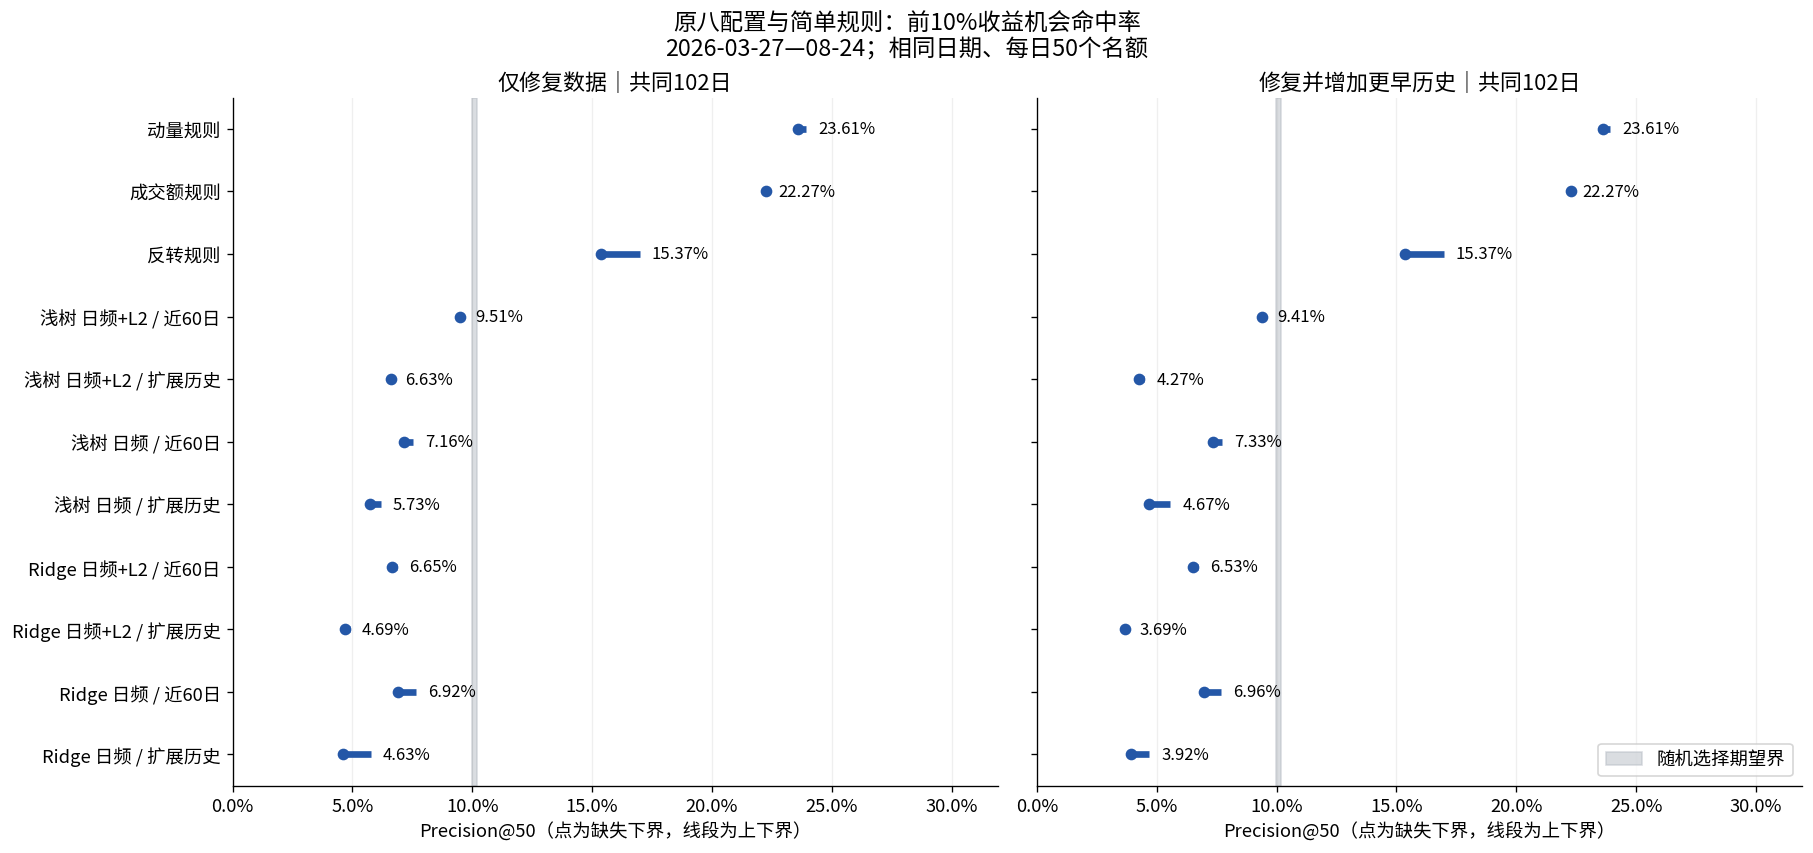

,method,days,hits,precision_lower,precision_upper,recall_lower,f1_lower,lift_lower
27,baseline_momentum,134,1638,0.244478,0.248358,0.023198,0.042375,2.406459
26,baseline_amount,134,1445,0.215672,0.215970,0.020443,0.037345,2.120567
28,baseline_reversal,134,980,0.146269,0.160299,0.013905,0.025396,1.442933
30,hist_all__last60,134,530,0.079104,0.079851,0.007500,0.013701,0.778637
36,ridge_daily__last60,134,470,0.070149,0.077612,0.006668,0.012179,0.691953
32,hist_daily__last60,134,461,0.068806,0.072388,0.006537,0.011939,0.678436
34,ridge_all__last60,134,414,0.061791,0.063284,0.005859,0.010703,0.608066
31,hist_daily__expanding,134,312,0.046567,0.053881,0.004419,0.008073,0.458534
35,ridge_daily__expanding,134,292,0.043582,0.051343,0.004140,0.007562,0.429494
29,hist_all__expanding,134,264,0.039403,0.041343,0.003742,0.006834,0.388347


In [8]:
figure, axes = plt.subplots(
    1, 2, figsize=(15, 7), sharex=True, sharey=True, layout="constrained"
)
methods = [
    "baseline_momentum",
    "baseline_amount",
    "baseline_reversal",
    "hist_all__last60",
    "hist_all__expanding",
    "hist_daily__last60",
    "hist_daily__expanding",
    "ridge_all__last60",
    "ridge_all__expanding",
    "ridge_daily__last60",
    "ridge_daily__expanding",
]
for axis, experiment, caption in zip(
    axes, ["corrected", "extended"], ["仅修复数据", "修复并增加更早历史"], strict=True
):
    view = (
        summary.loc[
            summary.experiment.eq(experiment) & summary.period.eq("development_common")
        ]
        .set_index("method")
        .loc[methods]
    )
    positions = np.arange(len(view))
    axis.hlines(
        positions,
        view.precision_lower,
        view.precision_upper,
        color="#2457A7",
        linewidth=4,
    )
    axis.scatter(view.precision_lower, positions, color="#2457A7", zorder=3)
    axis.axvspan(
        view.random_lower.iloc[0],
        view.random_upper.iloc[0],
        color="#B6BCC4",
        alpha=0.5,
        label="随机选择期望界",
    )
    for position, lower, upper in zip(
        positions, view.precision_lower, view.precision_upper, strict=True
    ):
        axis.text(upper + 0.005, position, f"{lower:.2%}", va="center", fontsize=10)
    axis.set_title(f"{caption}｜共同102日")
    axis.set_yticks(positions, [labels_map[method] for method in methods])
    axis.set_xlim(0, max(0.31, float(view.precision_upper.max()) + 0.08))
    axis.xaxis.set_major_formatter(PercentFormatter(1))
    axis.grid(axis="x", alpha=0.2)
    axis.set_xlabel("Precision@50（点为缺失下界，线段为上下界）")
axes[0].invert_yaxis()
axes[1].legend(loc="lower right")
figure.suptitle(
    "原八配置与简单规则：前10%收益机会命中率\n2026-03-27—08-24；相同日期、每日50个名额",
    fontsize=14,
)
figure.savefig(evidence / "development-precision.png", dpi=150, bbox_inches="tight")
plt.show()
extended_all = summary.loc[
    summary.experiment.eq("extended") & summary.period.eq("development_all")
].sort_values("precision_lower", ascending=False)
display(
    extended_all[
        [
            "method",
            "days",
            "hits",
            "precision_lower",
            "precision_upper",
            "recall_lower",
            "f1_lower",
            "lift_lower",
        ]
    ].round(6)
)

## 9. 原后续17日与完整指标

柱图报告每50个名额的已确认命中数。区间图报告原主候选 Precision 的保守配对差及5日区块双侧95%区间；显著性判断使用预定单侧下界。日频消融的缺失更多，保守界之差不能直接解释成实际 L2 效应。

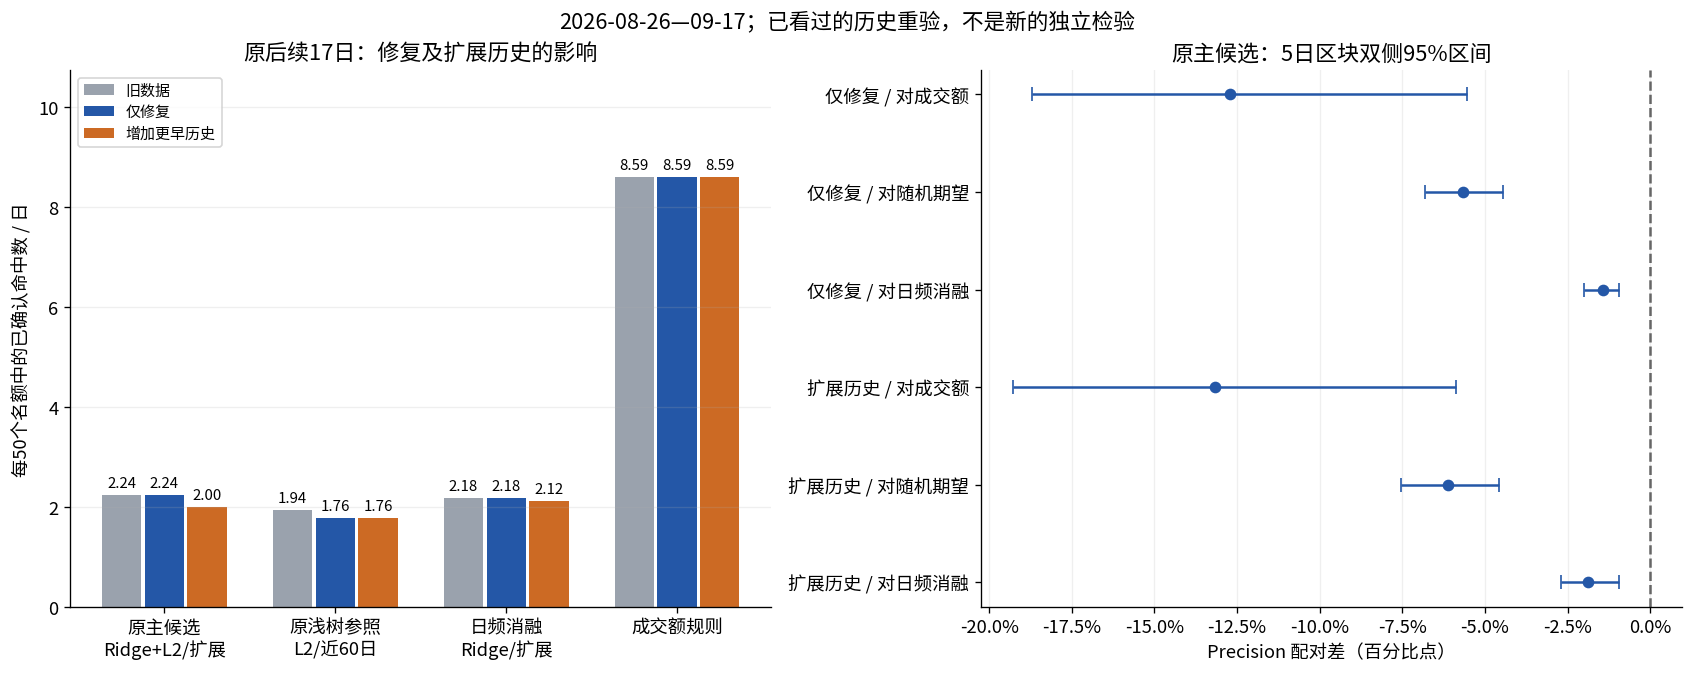

,experiment,method,hits,selected,selected_unknown,precision_lower,precision_upper,recall_lower,recall_upper,f1_lower,f1_upper,lift_lower,lift_upper
22,corrected,baseline_amount,146,850,0,0.171765,0.171765,0.016286,0.016501,0.029751,0.030109,1.695786,1.718194
23,corrected,hist_all__last60,30,850,0,0.035294,0.035294,0.003351,0.003393,0.006121,0.006190,0.348957,0.353247
24,corrected,ridge_all__expanding,38,850,3,0.044706,0.048235,0.004249,0.004634,0.007760,0.008455,0.442426,0.482474
25,corrected,ridge_daily__expanding,37,850,13,0.043529,0.058824,0.004138,0.005641,0.007558,0.010295,0.430934,0.587389
48,extended,baseline_amount,146,850,0,0.171765,0.171765,0.016286,0.016501,0.029751,0.030109,1.695786,1.718194
49,extended,hist_all__last60,30,850,0,0.035294,0.035294,0.003351,0.003393,0.006121,0.006190,0.348957,0.353247
50,extended,ridge_all__expanding,34,850,1,0.040000,0.041176,0.003801,0.003958,0.006942,0.007221,0.395782,0.412073
51,extended,ridge_daily__expanding,36,850,14,0.042353,0.058824,0.004026,0.005641,0.007354,0.010295,0.419259,0.587413


In [9]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5.5), layout="constrained")
role_methods = [
    parameters["primary"],
    "hist_all__last60",
    "ridge_daily__expanding",
    "baseline_amount",
]
followup_comparison = comparison.loc[comparison.period.eq("followup")]
positions = np.arange(len(role_methods))
for offset, experiment, caption, color in [
    (-0.25, "old", "旧数据", "#9AA2AD"),
    (0, "corrected", "仅修复", "#2457A7"),
    (0.25, "extended", "增加更早历史", "#CC6A24"),
]:
    part = (
        followup_comparison.loc[followup_comparison.experiment.eq(experiment)]
        .set_index("method")
        .loc[role_methods]
    )
    bars = axes[0].bar(
        positions + offset,
        part.precision_lower * 50,
        width=0.23,
        label=caption,
        color=color,
    )
    axes[0].bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
axes[0].set_xticks(
    positions,
    [
        "原主候选\nRidge+L2/扩展",
        "原浅树参照\nL2/近60日",
        "日频消融\nRidge/扩展",
        "成交额规则",
    ],
)
axes[0].set_ylabel("每50个名额中的已确认命中数 / 日")
axes[0].set_title("原后续17日：修复及扩展历史的影响")
axes[0].grid(axis="y", alpha=0.2)
axes[0].legend(loc="upper left", fontsize=9)
axes[0].set_ylim(0, float(followup_comparison.precision_upper.max() * 50) * 1.25)
paired = primary_intervals.loc[primary_intervals.period.eq("followup")].copy()
paired["caption"] = (
    paired.experiment.map({"corrected": "仅修复", "extended": "扩展历史"})
    + " / 对"
    + paired.comparator.map(
        {
            "baseline_amount": "成交额",
            "random": "随机期望",
            "ridge_daily__expanding": "日频消融",
        }
    )
)
y_positions = np.arange(len(paired))
axes[1].errorbar(
    paired.mean_difference,
    y_positions,
    xerr=[
        paired.mean_difference - paired.two_sided_lower_95,
        paired.two_sided_upper_95 - paired.mean_difference,
    ],
    fmt="o",
    capsize=4,
    color="#2457A7",
)
axes[1].set_yticks(y_positions, paired.caption)
axes[1].axvline(0, color="#666666", linestyle="--")
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xlabel("Precision 配对差（百分比点）")
axes[1].set_title("原主候选：5日区块双侧95%区间")
axes[1].grid(axis="x", alpha=0.2)
axes[1].invert_yaxis()
figure.suptitle("2026-08-26—09-17；已看过的历史重验，不是新的独立检验", fontsize=13)
figure.savefig(evidence / "followup-comparison.png", dpi=150, bbox_inches="tight")
plt.show()
followup_table = summary.loc[
    summary.period.eq("followup"),
    [
        "experiment",
        "method",
        "hits",
        "selected",
        "selected_unknown",
        "precision_lower",
        "precision_upper",
        "recall_lower",
        "recall_upper",
        "f1_lower",
        "f1_upper",
        "lift_lower",
        "lift_upper",
    ],
]
display(followup_table.round(6))

## 10. 保存结果与解释边界

数据修复的通过与模型预测优势的通过分别判断。旧失败记录保留；数据补齐不能把已看过的历史变成未见过的最终检验集。本轮不检验成交成本、净收益及获取实时 L2 的行动增益。

已核实修复传播和补齐历史，统计验收仍未通过。扩展组原主候选相对成交额的 Precision 差为−13.18个百分点，5日区块双侧95%区间为[−19.29, −5.88]个百分点。第一轮汇总代码误引用未安排的对照项，技术修复后从头重跑；两次已有数值产物逐字节相同，失败记录保留，不视为两个独立实验。


In [10]:
main = primary_intervals.loc[
    primary_intervals.period.eq("followup")
    & primary_intervals.comparator.eq("baseline_amount")
].copy()
main["exploratory_support"] = main.mean_difference.gt(0) & main.one_sided_lower_95.gt(0)
result = {
    "parameters": parameters,
    "panel_summary": panel_summary.to_dict("records"),
    "primary_followup": main.to_dict("records"),
    "quality": json.loads((evidence / "quality-result.json").read_text()),
    "verification": verification,
    "all_candidates_frozen": True,
    "no_production_state_written": True,
    "no_fresh_holdout": True,
    "runtime_research_only": True,
    "commit_merge_release_deploy_performed": False,
}
write_json(evidence / "result.json", result)
write_json(
    evidence / "artifact-manifest.json",
    [
        {
            "path": str(path.relative_to(evidence)),
            "bytes": path.stat().st_size,
            "sha256": sha256(path),
        }
        for path in sorted(evidence.rglob("*"))
        if path.is_file()
    ],
)
print(f"证据目录：{evidence}")
print("全部固定重训及独立核验完成。主判断（相对成交额规则）：")
display(
    main[
        [
            "experiment",
            "days",
            "mean_difference",
            "one_sided_lower_95",
            "exploratory_support",
        ]
    ].round(6)
)
print(
    "预测目标仍是参考收益前10%事件；当前修订数据和就绪假设不能证明历史真实接收、成交、净收益或观察价值。"
)

证据目录：/home/wsw/app/research-evidence/subscription-repaired-2026-09-22-2ans6qng
全部固定重训及独立核验完成。主判断（相对成交额规则）：


,experiment,days,mean_difference,one_sided_lower_95,exploratory_support
126,corrected,17,-0.127059,-0.180000,False
267,extended,17,-0.131765,-0.184706,False


预测目标仍是参考收益前10%事件；当前修订数据和就绪假设不能证明历史真实接收、成交、净收益或观察价值。


<a id="h04-protocol-20260921"></a>

## H04 2026-09-21 冻结方案与验收

运行前完整记录：[冻结 README](/home/wsw/app/research-evidence/subscription-revalidation-2026-09-21-plweybse/preregistered-README.md)。以下为便于阅读迁入的说明，原冻结记录不回写。

- 运行前固定（2026-09-21，`156e904a1e1b6b9aff1ed8d5fffb3271b19819ee`）:
  - T=`2025-12-22..2026-09-17` 共181日；12月19日只供首日特征，9月18日只供退出。
    先逐值恢复 H02 原 `hist_all`/成交额对照79日预测，不算新证据。
  - 原四模型/输入×last60/expanding，共八候选；expanding 从60个合法成熟日开始。
    参数、日期权重、缺失处理、seed=20260919及月度更新沿用 H02。
  - 开发/选择段 `03-27..08-24` 共102日，按 top50 排名缺失下界均值选模型及三规则
    中的对照，同分按名。8月25日标签成熟太晚而不参与选择；已看过历史不算独立确认。
  - 新增段 `08-26..09-17` 共17日，打开效果前落盘选择；8月沿用原模型，9月月首更新。
    只评价主候选、规则、原 `hist_all/last60`；主候选含 L2 时另列同算法/窗口日频消融。
  - 主差及缺失界沿用 H02；5日循环区块10,000次，另列1/3日敏感性及覆盖/IC/分月结果。
- Acceptance: 输入/时序/推理一致性和旧预测恢复通过；新增两方覆盖各≥98%、保守均值
  差≥0.02且单侧95%下界>0时，仅称17日短期支持；没有新增50日硬门槛。
- Stop: 八候选一次比较、新增段打开一次；统计失败不加候选、调阈值或重选赢家。


<a id="h04-evidence-20260921"></a>

## H04 2026-09-21 原结果与归档

这里描述修复前的原实验，其可执行 Notebook 和输入以本节原归档为准；本文件当前代码执行后续修复重验。

- Evidence（2026-09-21）: [`revalidation.ipynb`](revalidation.ipynb) 和
  `validate_training.py::run_revalidation`；原 `run_research` 语义及79日预测保持一致。
  输入181日、938,691个股票日、937,047个已知标签，1,094文件/337,466,193字节。

**原结果。** 开发段八模型均低于成交额0.507549；最优模型为
`ridge_all__expanding`（0.501579），因此固定它与成交额对照。新增段结果如下：

| 角色 | 平均可观察排名 | 相对成交额的保守差 | 标签覆盖 |
| --- | ---: | ---: | ---: |
| 主候选：Ridge+L2/expanding | 0.501070 | +0.010012 | 99.5294% |
| 原参照：浅树+L2/last60 | 0.491256 | +0.001747 | 99.8824% |
| 日频消融：Ridge/expanding | 0.503280 | +0.006530 | 98.4706% |

成交额可观察排名0.488804、覆盖100%；主差单侧95%下界 **−0.085075**，双侧区间
**[−0.102866, +0.127229]**，1/3日下界也小于零。8月4日差+0.104144，9月13日
−0.018952，未达到短期支持条件。日频缺失更多，保守界排序不能证明稳定 L2 增量。

归档 `/home/wsw/app/research-evidence/subscription-revalidation-2026-09-21-plweybse/`
保留运行前方案、源码/lock、输入、55次拟合的模型/日程、全部预测、冻结选择、
`new-summary.json`、图及 Notebook，至用户决定及审查结束。`verify_outputs.py` 独立
重算51份新增预测的指标/区间，重载核对31,236个预测值；8月模型延续，9月只更新一次，
最新训练目标日8月28日。原输入哈希未变；训练回归38 passed、Ruff/Mypy及边界反例通过。


<a id="h04-protocol-20260922"></a>

## H04/H05 2026-09-22 修复及补齐历史后的冻结重验方案

运行前完整记录：[冻结 README](/home/wsw/app/research-evidence/subscription-repaired-2026-09-22-2ans6qng/source-README.md)。以下为便于阅读迁入的说明，原冻结记录不回写。

本次是 H04/H05 原候选的数据修复重验，继续使用 `revalidation.ipynb`；旧 Notebook、输入、
模型和失败结果已在原证据目录冻结，保持不变。基线为
`46ecdc1dba1a390cf7cfe8560f296cb7fcd0cbbf`，工作树已有的数据维护记录保留。
实际入库记录补齐的是 **2025-11-25**；2025-11-15 是非交易日。当前日历核对确认
`2025-11-05..2026-09-18` 共215个交易日的沪深分钟、历史 L2 Feature 和日频 Feature
均存在，Label 覆盖至9月17日，无中间分区缺口。

- 可观察结果：修复传播核验、固定模型重训、逐日预测、Precision/Recall/F1/Lift、与旧结果
  的同日期对照；修改仅限本卷宗及隔离证据，不改正式契约、生产模型或数据。
- 两个固定输入范围：A `corrected` 沿用原181个目标日 `2025-12-22..2026-09-17`；
  B `extended` 使用213个目标日 `2025-11-06..2026-09-17`。最早前一日只供特征，
  9月18日只供退出标签。A 开发段仍为102日 `03-27..08-24`；B 从至少60个已成熟
  目标日开始，为134日 `02-03..08-24`，另单列与 A 相同的102日。后续段均为原17日
  `08-26..09-17`；8月25日仍不进入开发选择统计。
- 原八配置、39列特征、日期权重、缺失处理、月度重训、seed=20260919、K=50及
  `y_rank_return > 0.9` 均固定；直接复用原训练代码。主候选仍是
  `ridge_all__expanding`，后续段仍只看它、`ridge_daily__expanding`、
  `hist_all__last60` 和成交额对照；本次不按新结果重选后续赢家。
- 八配置在开发段完整列出；A/B 均从8月模型状态接续，9月1日按原计划更新。
  用 H05 的日期等权命中指标和缺失上下界评价，平均排名只作补充；主比较为
  Precision 下界减成交额上界，另列随机期望和日频消融。
  5日循环区块重采样10,000次、seed=20260922，1/3日仅作敏感性分析。
- 工程验收：当前修复产物与维护证据哈希一致；冻结输入无重复 key、分区缺失及原巨型
  标签并列异常；训练只使用当时已成熟的标签；保存模型可恢复预测；名单与命中计数可
  独立重算；缺失边界与 sklearn 完整事件赋值一致；Notebook 从头执行并检查图表。
  旧预测逐值恢复只适用于修复未影响的日期/字段，不能要求修复后的标签、模型等于旧值。
- 统计判断沿用 H05：均值差>0且5日区块单侧95%下界>0，至多称为相对该对照的
  探索性支持；否则报告不支持或不确定。不存在新增50日硬门槛。
- Stop：上述两组固定重训各执行一次；技术错误可在同口径修复，不按统计结果改变模型、
  K、目标或日期。历史区间均已参与研究，补录更早日期不产生新的独立最终验证集。
  本轮使用当前更正版本，只能检验“假设正确数据及时到达”的历史情景；P 22:00和
  T 09:00仍是就绪假设，不能声称复现当时真实接收、修订可用时点、净收益或观察价值。


<a id="h04-evidence-20260922"></a>

## H04/H05 2026-09-22 重验结果、失败与归档

**重验结果（2026-09-22）**：已核实已知重复修复及分区补齐，固定模型的机会命中优势仍
未通过。A 为181日、938,691个股票日、937,043个已知标签；B 为213日、1,103,651个
股票日、1,101,724个已知标签。训练输入冻结1,286份文件、396,346,201字节，另复制六个
分钟对象及 Meta 共76,118,655字节。原范围恰有三个 payload 改变：6月9日历史 L2
Feature、6月8/9日 Label；15个相关分钟/Feature/Label 与维护发布哈希一致。
6月8/9日窗口现在为25,723/25,619行且不再相同；6月8日 Label 最大并列组为1，
213日中的最大并列组为4。此次未再次全量解压 raw 或重算逐笔，未宣称其他日期的经济
真实性已全部审查。

**共同102日对照**（均为原主候选，日期、K、标签和统计口径相同）：

| 数据与训练历史 | top50 平均排名下界 | Precision 下界 | 命中/5,100 |
| --- | ---: | ---: | ---: |
| H04/H05 旧输入 | 0.501579 | 4.4902% | 229 |
| A：仅修复 | 0.500935 | 4.6863% | 239 |
| B：修复并增加更早历史 | 0.508825 | 3.6863% | 188 |

当前成交额对照在相同102日为0.507818、22.2745%（1,136/5,100）。B 的平均排名虽略高，
上尾命中反而更低；两种指标衡量不同目标，不能用排名略高于0.5替代机会命中验收。
B 完整134日中，八模型最高 Precision 下界为浅树+L2/近60日的 **7.9104%**，上界
7.9851%；随机期望为9.9831%–10.1668%，成交额为21.5672%–21.5970%，动量为
24.4478%–24.8358%。八模型的 Precision 上界都低于随机期望下界。本表和排序仅为
固定候选的完整诊断，不据此重新选择后续段赢家或采用简单规则。

**原后续17日**（2026-08-26..09-17；已看过的历史重验；以下均为缺失标签保守下界）：

| 方案 | 命中/850 | Precision | Recall | F1 | Lift |
| --- | ---: | ---: | ---: | ---: | ---: |
| A 原主候选：Ridge+L2/扩展历史 | 38 | 4.4706% | 0.4249% | 0.7760% | 0.4424 |
| B 原主候选：Ridge+L2/扩展历史 | 34 | 4.0000% | 0.3801% | 0.6942% | 0.3958 |
| B 日频消融：Ridge/扩展历史 | 36 | 4.2353% | 0.4026% | 0.7354% | 0.4193 |
| A/B 原参照：浅树+L2/近60日 | 30 | 3.5294% | 0.3351% | 0.6121% | 0.3490 |
| A/B 成交额对照 | 146 | 17.1765% | 1.6286% | 2.9751% | 1.6958 |

A/B 主候选分别有3/1个未知入选标签，Precision 上界为4.8235%/4.1176%；成交额没有
未知入选标签。随机期望为9.9937%–10.1191%。原旧主候选同段也是38次命中；修复没有
改变其总命中数，但逐日名单、缺失数和配对区间有所变化。Recall 与 F1 是日期等权统计，
并未把未知标签宣称为真实负例；完整上下界见 `summary.csv`。

相对成交额的主 Precision 配对差：A 为 **−12.7059个百分点**，5日区块单侧95%下界
−18.0000个百分点，双侧95%区间为[−18.7059, −5.5294]个百分点；B 为
**−13.1765个百分点**，单侧下界−18.4706，双侧区间[−19.2941, −5.8824]个百分点。
两组均不满足探索性支持条件。这是固定参考标签上的失败证据，不等于证明任何昨日 L2
建模方法都无效；纯日频消融的保守界之差也不能单独认定实际 L2 增量为负。

最终证据目录：`/home/wsw/app/research-evidence/subscription-repaired-2026-09-22-2ans6qng/`。
`revalidation.ipynb` 已从头执行10个代码单元，`revalidation.html` 为浏览版本。
保存代码/环境、运行前方案、输入、副本哈希、110次拟合及全部574份逐日预测、逐日名单、
命中计数、分月结果、全部配对区间和图。独立检查覆盖2,732个模型日、5,464次 sklearn
极端赋值验证；110个模型重载恢复569,814个拟合日预测值；94份未受修复影响的旧预测、
99份共同近60日窗口预测逐值一致；另核对24份8月模型延续预测。6组主区间重采样均
独立循环复算。1,298份当前输入文件运行后哈希未变。相关预处理/数据集/推理测试
13 passed，Notebook 的 Ruff 与导出代码定向 Mypy 通过；未运行无关的全仓库测试。

首次运行在统计汇总中引用了未安排的浅树日频后续消融；修复为只比较预定且存在的配对，
原主候选的日频配对仍强制要求存在，再从头执行。第一次输入、模型、Notebook 和错误保存于
`/home/wsw/app/research-evidence/subscription-repaired-2026-09-22-1_mjcyvw/`，两次的
逐日排名、命中表、汇总及旧新对照逐字节一致，不算两次独立实验。

本轮完成了原候选的固定重验，H04/H05 保持 open。后续需要先明确事件与收益/风险决策
的关系，再预先固定直接预测事件概率的有限候选及对照；不能将分类命中提升自动解释成
净 alpha 或观察价值。设计仍为研究草案；只修改研究工作树，没有 commit、merge、release
或 deploy，也没有写入正式数据或生产模型。


<a id="h04-reproduce-20260921"></a>

## H04 2026-09-21 原实验的精确恢复

下面恢复的是2026-09-21原 H04，用旧181日冻结输入；不是本次修复后的训练。
原 H02 证据目录用于核对旧79日预测：

```bash
cd /home/wsw/app/dev/trading
.venv/bin/python -B - <<'PY'
from pathlib import Path
import runpy

source = Path('/home/wsw/app/dev/trading')
driver = runpy.run_path(str(source / 'research/subscription-training/validate_training.py'))
evidence = driver['run_revalidation'](
    source_root=source,
    storage_root=Path('/home/wsw/app/research-evidence/subscription-revalidation-2026-09-21-plweybse/inputs'),
    evidence_parent=Path('/home/wsw/app/research-evidence'),
    previous_evidence=Path('/home/wsw/app/research-evidence/subscription-training-2026-09-19-po2l15iv'),
)
print(evidence)
PY
```

若当前代码树已变化，先在独立的本地 checkout 恢复记录中的基线 commit，再解开
`source.tar` 覆盖这个独立 checkout 的运行文件，并将归档的 `validate_training.py` 和
`preregistered-README.md` 放回该 checkout 的 `research/subscription-training/`；以它
作为 cwd 和 source_root，从保存的 `inputs/` 执行。不要覆盖正在工作的仓库或正式数据。
依赖按归档 `uv.lock` 恢复；Notebook 的 kernel 必须指向对应 Python 3.13 锁定环境。

检查 `input-manifest.json`、模型和预测内容、`fit-schedule.json`、`selection-frozen.json`
与 H02 的 `final-summary.json` 或 H04 的 `new-summary.json`。
逐次 wall time 可以变化，候选、输入、训练日期、预测和主指标
必须一致。所有复跑都是同一实验的恢复，不是新的样本外成功机会。


<a id="h04-reproduce-20260922"></a>

## H04/H05 2026-09-22 修复重验的精确恢复

恢复依赖的两份维护证据见 [6 月修复](opportunity_metrics.ipynb#level2-duplicate-2026-06)与 [11 月补齐](opportunity_metrics.ipynb#level2-gap-2025-11-25)。

2026-09-22 修复重验使用当前 `revalidation.ipynb` 和 `trading-research` 内核；从头执行会
只读当前正式输入，重新快照并建立新证据目录。需要精确恢复本次数值时，使用
`subscription-repaired-2026-09-22-2ans6qng` 中的 `source.tar`、
`source-revalidation.ipynb`、`source-validate_training.py` 和锁定环境；在独立恢复目录合并
`inputs/` 与 `quality-inputs/`，将 Notebook 的 `storage_root` 指向该目录，将 `repairs`
指向已归档的两个 `maintenance-records/` 子目录。还须从上文两个维护证据目录的 `new/`
复制分钟 Meta 引用的六个沪深逐笔 payload 和 Meta；逐笔内容不参与本轮计算，但既有
Meta 契约会核对它们的存在及大小，不能只恢复分钟文件。保留代码引用的 H04/H05 原证据目录，
它们仍用于旧结果比较及不受修复影响的预测恢复。不要向正式数据覆盖这些历史副本。
完整复算将产生相同预测、计数及区间；执行耗时可以变化。最终 HTML、输入 manifest、
模型日程和 `verification.json` 可直接用于只读复核。
